In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv("carprices.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Car Model      13 non-null     object
 1   Mileage        13 non-null     int64 
 2   Sell Price($)  13 non-null     int64 
 3   Age(yrs)       13 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 548.0+ bytes


In [5]:
df.describe()

,Mileage,Sell Price($),Age(yrs)
count,13.000000,13.000000,13.000000
mean,60884.615385,26023.076923,5.307692
std,19185.665055,8003.661021,1.652504
min,22500.000000,12000.000000,2.000000
25%,52000.000000,20000.000000,5.000000
50%,59000.000000,26100.000000,5.000000
75%,72000.000000,32000.000000,6.000000
max,91000.000000,40000.000000,8.000000


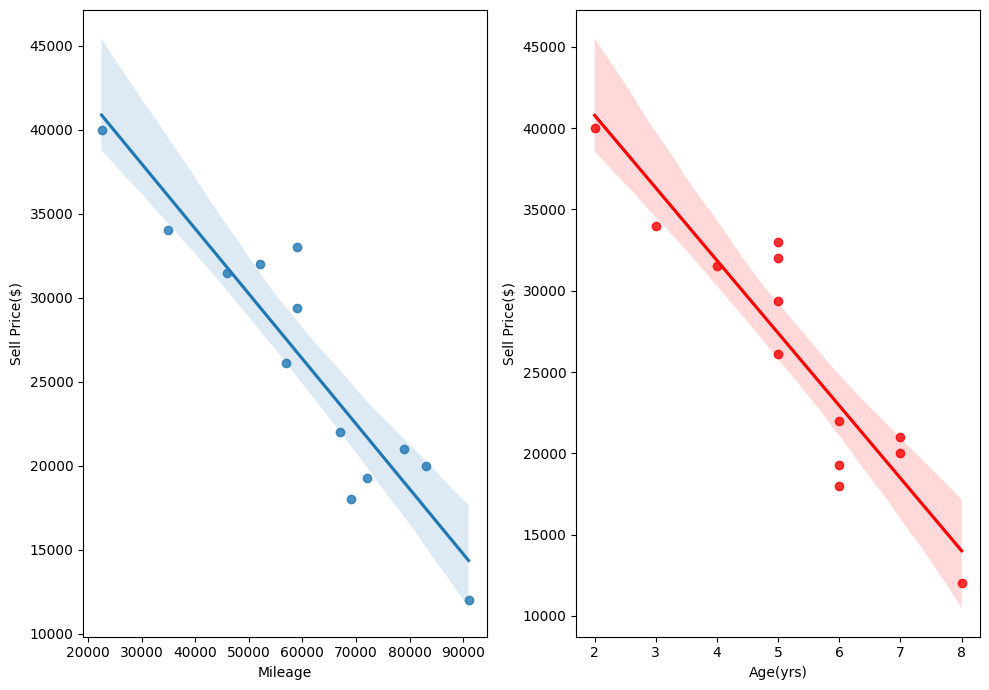

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(10, 7))

sns.regplot(data=df, x="Mileage", y="Sell Price($)", ax=ax[0])

sns.regplot(data=df, x="Age(yrs)", y="Sell Price($)", ax=ax[1], color = "red")

plt.tight_layout()
plt.show()

##Label encoding


In [13]:
le = LabelEncoder()

In [16]:
dfle = df
dfle["Car Model"] = le.fit_transform(dfle["Car Model"])
dfle

,Car Model,Mileage,Sell Price($),Age(yrs)
0,1,69000,18000,6
1,1,35000,34000,3
2,1,57000,26100,5
3,1,22500,40000,2
4,1,46000,31500,4
5,0,59000,29400,5
6,0,52000,32000,5
7,0,72000,19300,6
8,0,91000,12000,8
9,2,67000,22000,6


In [20]:
print("Car Model to Number Mapping:")
for number, car_model in enumerate(le.classes_):
    print(f"{car_model} -> {number}")

Car Model to Number Mapping:
Audi A5 -> 0
BMW X5 -> 1
Mercedez Benz C class -> 2


In [26]:
x = dfle[["Car Model", "Mileage", "Age(yrs)"]].values
y = dfle["Sell Price($)"].values
x, y

(array([[    1, 69000,     6],
        [    1, 35000,     3],
        [    1, 57000,     5],
        [    1, 22500,     2],
        [    1, 46000,     4],
        [    0, 59000,     5],
        [    0, 52000,     5],
        [    0, 72000,     6],
        [    0, 91000,     8],
        [    2, 67000,     6],
        [    2, 83000,     7],
        [    2, 79000,     7],
        [    2, 59000,     5]]),
 array([18000, 34000, 26100, 40000, 31500, 29400, 32000, 19300, 12000,
        22000, 20000, 21000, 33000]))

##One hot encoding

In [27]:
ct = ColumnTransformer([("Car Model", OneHotEncoder(), [0])], remainder="passthrough")

In [28]:
x = ct.fit_transform(x)
x

array([[0.00e+00, 1.00e+00, 0.00e+00, 6.90e+04, 6.00e+00],
       [0.00e+00, 1.00e+00, 0.00e+00, 3.50e+04, 3.00e+00],
       [0.00e+00, 1.00e+00, 0.00e+00, 5.70e+04, 5.00e+00],
       [0.00e+00, 1.00e+00, 0.00e+00, 2.25e+04, 2.00e+00],
       [0.00e+00, 1.00e+00, 0.00e+00, 4.60e+04, 4.00e+00],
       [1.00e+00, 0.00e+00, 0.00e+00, 5.90e+04, 5.00e+00],
       [1.00e+00, 0.00e+00, 0.00e+00, 5.20e+04, 5.00e+00],
       [1.00e+00, 0.00e+00, 0.00e+00, 7.20e+04, 6.00e+00],
       [1.00e+00, 0.00e+00, 0.00e+00, 9.10e+04, 8.00e+00],
       [0.00e+00, 0.00e+00, 1.00e+00, 6.70e+04, 6.00e+00],
       [0.00e+00, 0.00e+00, 1.00e+00, 8.30e+04, 7.00e+00],
       [0.00e+00, 0.00e+00, 1.00e+00, 7.90e+04, 7.00e+00],
       [0.00e+00, 0.00e+00, 1.00e+00, 5.90e+04, 5.00e+00]])

In [30]:
x = x[:, 1:]
x

array([[1.00e+00, 0.00e+00, 6.90e+04, 6.00e+00],
       [1.00e+00, 0.00e+00, 3.50e+04, 3.00e+00],
       [1.00e+00, 0.00e+00, 5.70e+04, 5.00e+00],
       [1.00e+00, 0.00e+00, 2.25e+04, 2.00e+00],
       [1.00e+00, 0.00e+00, 4.60e+04, 4.00e+00],
       [0.00e+00, 0.00e+00, 5.90e+04, 5.00e+00],
       [0.00e+00, 0.00e+00, 5.20e+04, 5.00e+00],
       [0.00e+00, 0.00e+00, 7.20e+04, 6.00e+00],
       [0.00e+00, 0.00e+00, 9.10e+04, 8.00e+00],
       [0.00e+00, 1.00e+00, 6.70e+04, 6.00e+00],
       [0.00e+00, 1.00e+00, 8.30e+04, 7.00e+00],
       [0.00e+00, 1.00e+00, 7.90e+04, 7.00e+00],
       [0.00e+00, 1.00e+00, 5.90e+04, 5.00e+00]])

## Linear regression


In [33]:
model = LinearRegression()

In [34]:
model.fit(x, y)

LinearRegression()

In [35]:
model.score(x, y)

0.9417050937281082

In [37]:
print(model.predict([[0, 1, 45000, 4]]))  #mercedez benz that is 4 yr old with mileage 45000
print(model.predict([[1, 0, 86000, 7]])) #BMW X5 that is 7 yr old with mileage 86000

[36991.31721062]
[11080.74313219]
